In [2]:
library(ucidata)
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
head(wine)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<fct>
1,7.4,0.70,0.00,1.9,0.076,11,34,0.9978,3.51,0.56,9.4,5,Red
2,7.8,0.88,0.00,2.6,0.098,25,67,0.9968,3.20,0.68,9.8,5,Red
3,7.8,0.76,0.04,2.3,0.092,15,54,0.9970,3.26,0.65,9.8,5,Red
4,11.2,0.28,0.56,1.9,0.075,17,60,0.9980,3.16,0.58,9.8,6,Red
5,7.4,0.70,0.00,1.9,0.076,11,34,0.9978,3.51,0.56,9.4,5,Red
6,7.4,0.66,0.00,1.8,0.075,13,40,0.9978,3.51,0.56,9.4,5,Red


1.

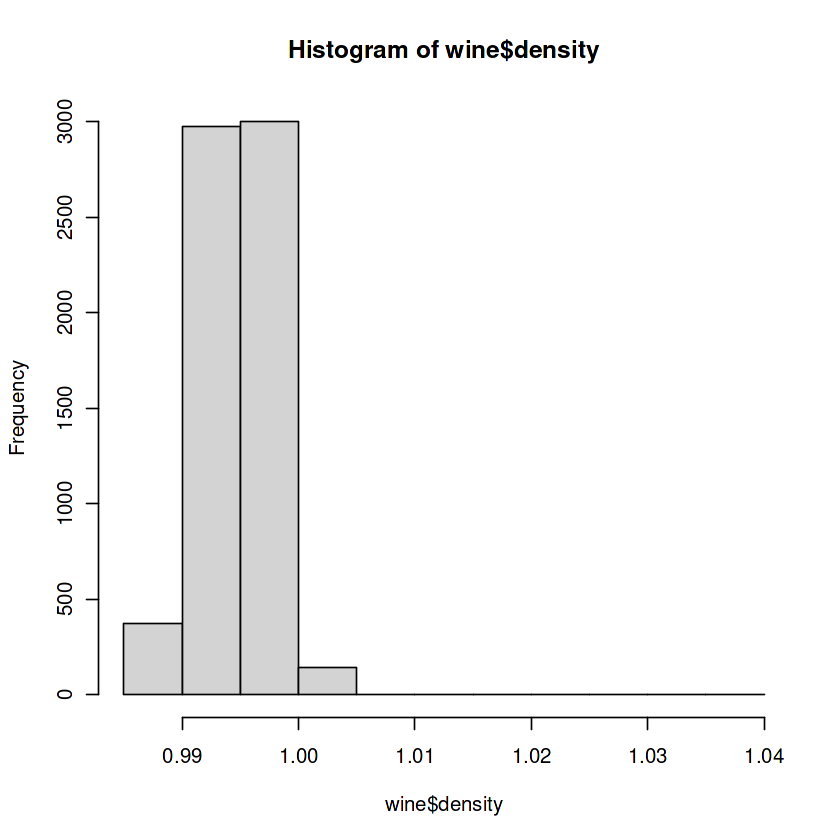

In [4]:
hist(wine$density)

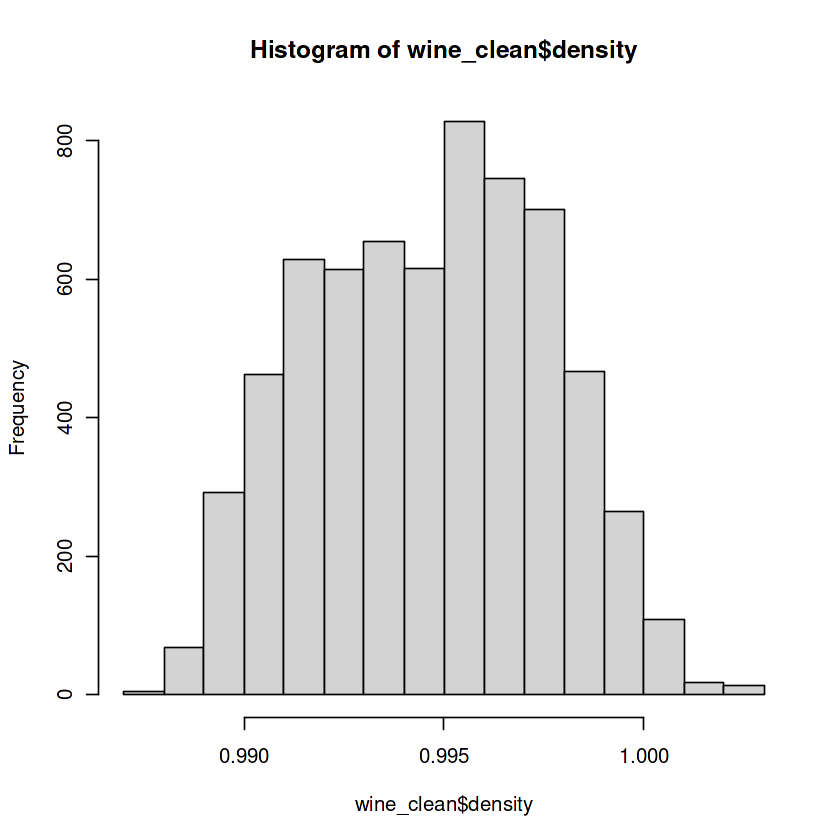

In [10]:
wine_clean <- wine %>%
  filter(
    density > quantile(density, 0.001, na.rm = TRUE) &
    density < quantile(density, 0.999, na.rm = TRUE)
  )

hist(wine_clean$density)


2.

In [24]:
# Re-create the 0/1 column safely
wine_clean <- wine_clean %>%
  mutate(type_num = ifelse(tolower(trimws(color)) == "white", 1, 0))

# Check to make sure we now have a good mix of 0s and 1s!
table(wine_clean$type_num)


   0    1 
1593 4887 

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


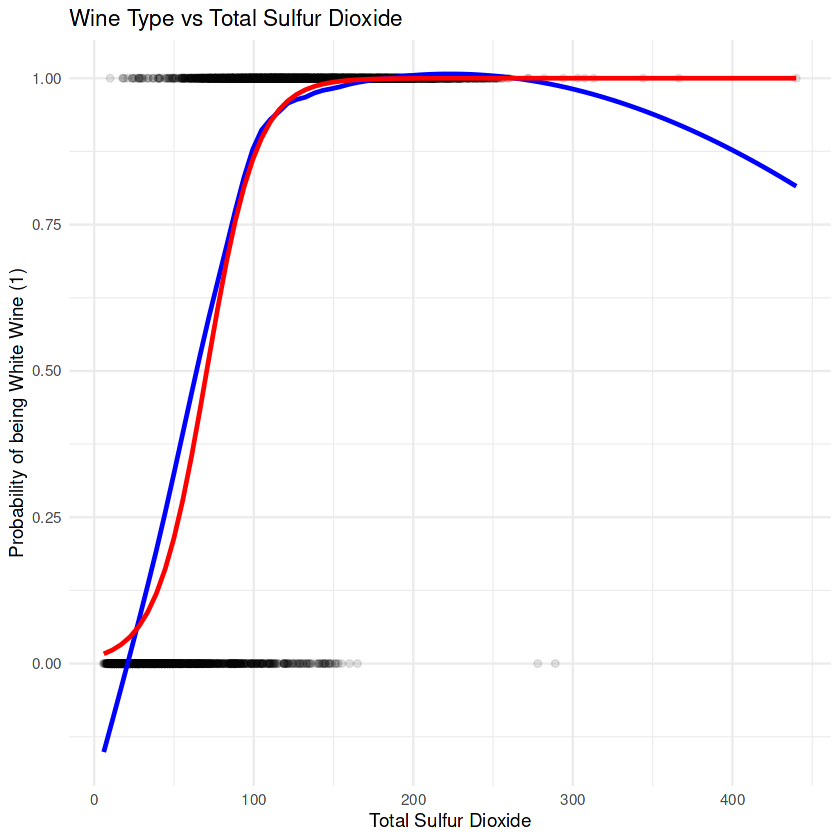

In [25]:
ggplot(wine_clean, aes(x = total_sulfur_dioxide, y = type_num)) +
  geom_point(alpha = 0.1) + 
  geom_smooth(method = "loess", color = "blue", se = FALSE) +
  geom_smooth(method = "glm", method.args = list(family = "binomial"), color = "red", se = FALSE) +
  labs(
    title = "Wine Type vs Total Sulfur Dioxide",
    y = "Probability of being White Wine (1)",
    x = "Total Sulfur Dioxide"
  ) +
  theme_minimal()

3.

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


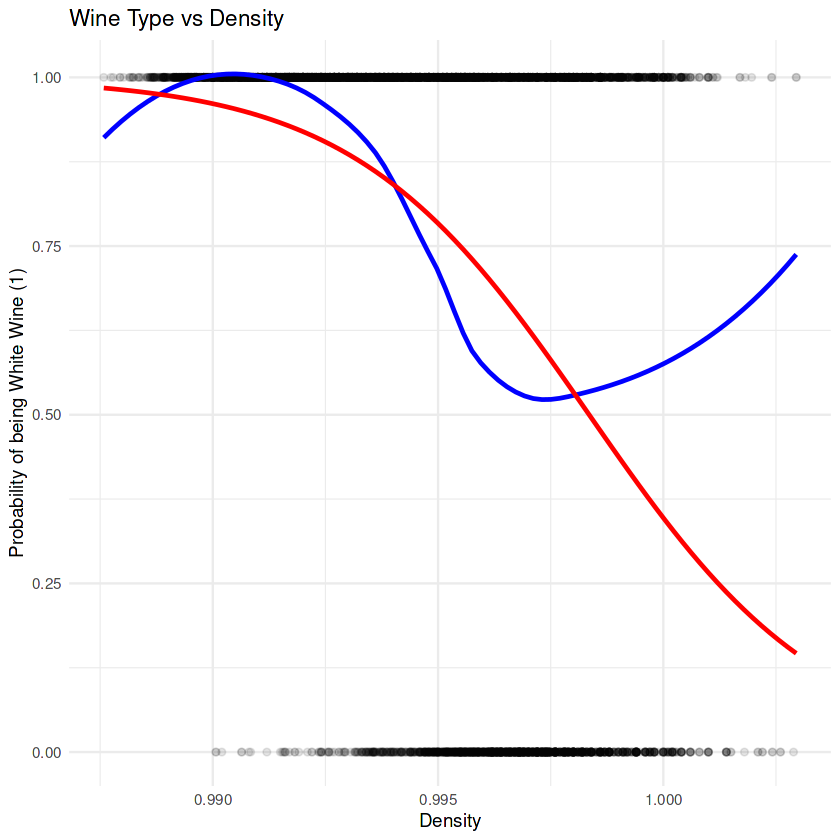

In [26]:
ggplot(wine_clean, aes(x = density, y = type_num)) +
  geom_point(alpha = 0.1) +
  geom_smooth(method = "loess", color = "blue", se = FALSE) +
  geom_smooth(method = "glm", method.args = list(family = "binomial"), color = "red", se = FALSE) +
  labs(
    title = "Wine Type vs Density",
    y = "Probability of being White Wine (1)",
    x = "Density"
  ) +
  theme_minimal()

4.

In [28]:

mod_no_int <- glm(type_num ~ density + total_sulfur_dioxide, 
                  data = wine_clean, family = "binomial")


mod_int <- glm(type_num ~ density * total_sulfur_dioxide, 
               data = wine_clean, family = "binomial")

mod_no_int
mod_int


Call:  glm(formula = type_num ~ density + total_sulfur_dioxide, family = "binomial", 
    data = wine_clean)

Coefficients:
         (Intercept)               density  total_sulfur_dioxide  
           801.36651            -810.83585               0.07291  

Degrees of Freedom: 6479 Total (i.e. Null);  6477 Residual
Null Deviance:	    7228 
Residual Deviance: 1607 	AIC: 1613


Call:  glm(formula = type_num ~ density * total_sulfur_dioxide, family = "binomial", 
    data = wine_clean)

Coefficients:
                 (Intercept)                       density  
                    1646.390                     -1660.134  
        total_sulfur_dioxide  density:total_sulfur_dioxide  
                      -8.578                         8.690  

Degrees of Freedom: 6479 Total (i.e. Null);  6476 Residual
Null Deviance:	    7228 
Residual Deviance: 1515 	AIC: 1523

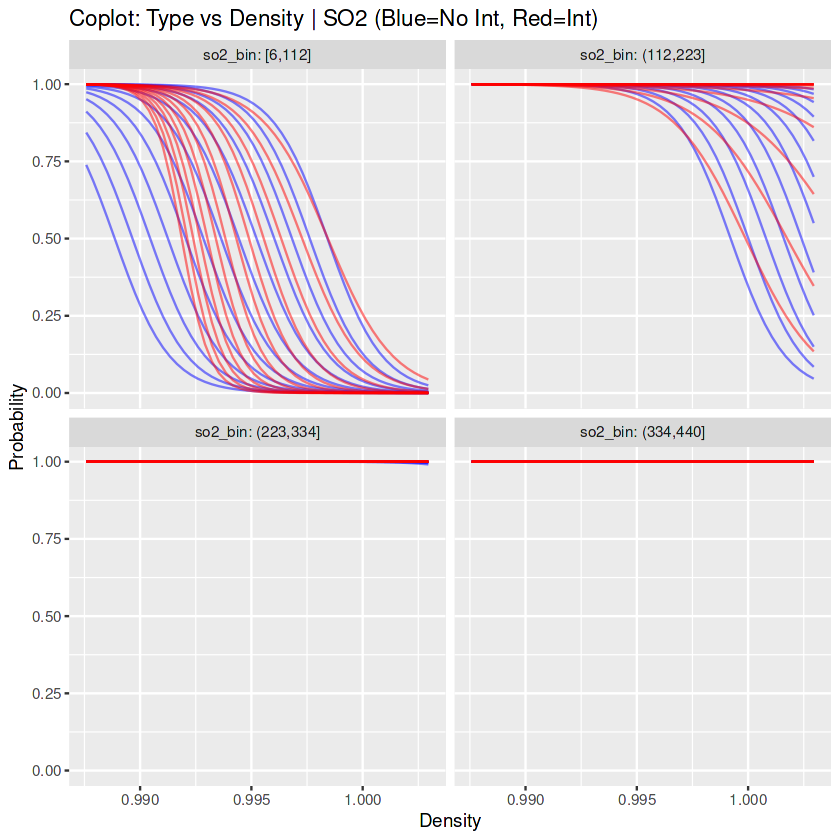

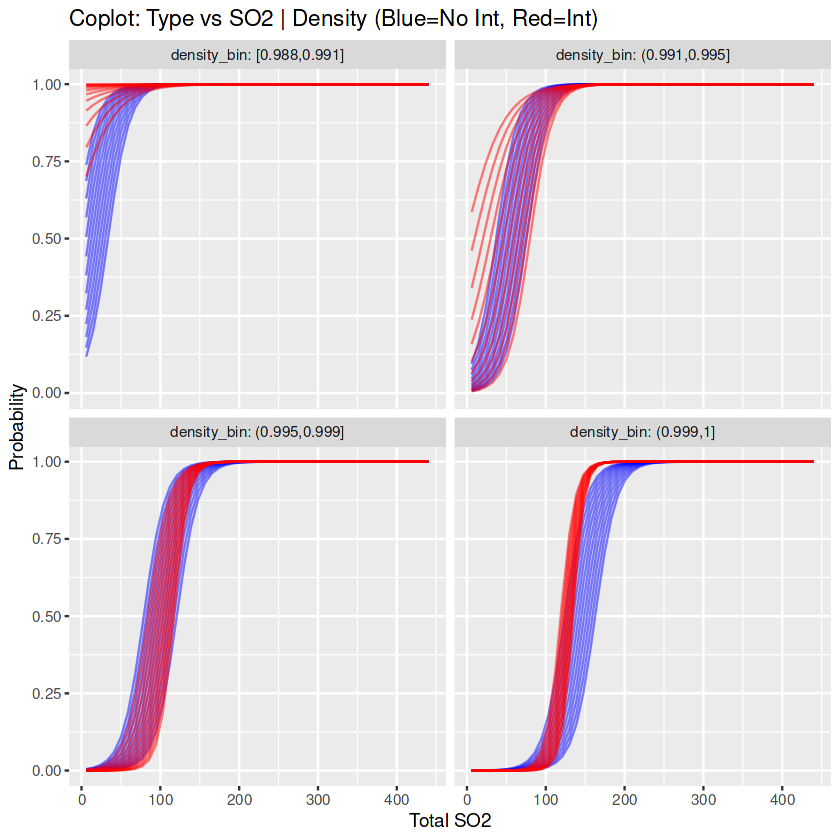

In [29]:
grid <- expand.grid(
  density = seq(min(wine_clean$density), max(wine_clean$density), length.out = 50),
  total_sulfur_dioxide = seq(min(wine_clean$total_sulfur_dioxide), max(wine_clean$total_sulfur_dioxide), length.out = 50)
)

grid$pred_no_int <- predict(mod_no_int, newdata = grid, type = "response")
grid$pred_int <- predict(mod_int, newdata = grid, type = "response")

wine_clean$density_bin <- cut_number(wine_clean$density, n = 4)
wine_clean$so2_bin <- cut_number(wine_clean$total_sulfur_dioxide, n = 4)
grid$density_bin <- cut_number(grid$density, n = 4)
grid$so2_bin <- cut_number(grid$total_sulfur_dioxide, n = 4)

ggplot() +
  geom_line(data = grid, aes(x = density, y = pred_no_int, group = total_sulfur_dioxide), color = "blue", alpha = 0.5) +
  geom_line(data = grid, aes(x = density, y = pred_int, group = total_sulfur_dioxide), color = "red", alpha = 0.5) +
  facet_wrap(~ so2_bin, labeller = label_both) +
  labs(title = "Coplot: Type vs Density | SO2 (Blue=No Int, Red=Int)", y = "Probability", x = "Density")

ggplot() +
  geom_line(data = grid, aes(x = total_sulfur_dioxide, y = pred_no_int, group = density), color = "blue", alpha = 0.5) +
  geom_line(data = grid, aes(x = total_sulfur_dioxide, y = pred_int, group = density), color = "red", alpha = 0.5) +
  facet_wrap(~ density_bin, labeller = label_both) +
  labs(title = "Coplot: Type vs SO2 | Density (Blue=No Int, Red=Int)", y = "Probability", x = "Total SO2")

5.

The coplots illustrate conditional relationship among wine type, density, and total sulfur dioxide; highlighting the necessity of an interaction term in the modeling process. In the additive model lacking an interaction term, the predicted probability curves remain generally parallel across the conditioned panels, incorrectly assuming that the effect of density on the likelihood of a wine being classified as white is entirely independent of its total sulfur dioxide content. Conversely, the model incorporating the interaction term exhibits clear variations in the slopes and trajectories of the probability curves across different conditioning bins.